In [5]:
import numpy as np
import pandas as pd

In [15]:

df = pd.read_csv("spam.csv", encoding="latin1")
print(df.shape)
df['v2'] = df['v2'].str.lower()
df['v2'] = df['v2'].str.replace(r'[^a-z\s]', '', regex=True)
df['v2']=df['v2'].str.split(" ")
stop_words = {
    "the", "is", "at", "which", "on", "and", "a", "an",
    "to", "in", "for", "of", "with", "that", "this", "it","i","u","he"
}
df['v2'] = df['v2'].apply(
    lambda words: [w for w in words if w not in stop_words]
)


(5572, 5)


In [16]:
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  [go, until, jurong, point, crazy, available, o...        NaN   
1   ham                        [ok, lar, joking, wif, oni]        NaN   
2  spam  [free, entry, , wkly, comp, win, fa, cup, fina...        NaN   
3   ham  [dun, say, so, early, hor, c, already, then, say]        NaN   
4   ham  [nah, dont, think, he, goes, usf, he, lives, a...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [17]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load
df = pd.read_csv("spam.csv", encoding="latin1")
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Basic preprocessing
stop_words = {"the","is","at","on","and","a","an","to","in","for","of","with","that","this","it"}

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

df['words'] = df['text'].apply(preprocess)


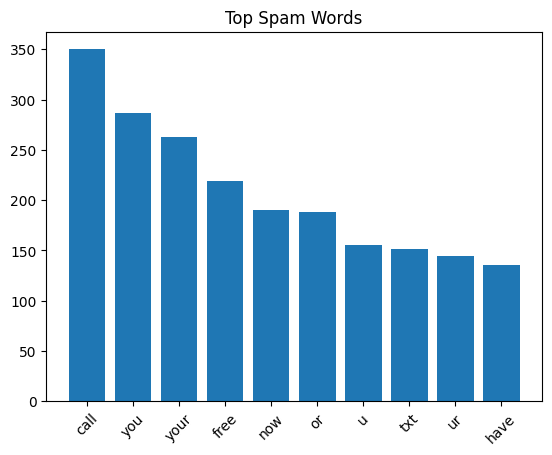

In [18]:
spam_words = []
ham_words = []

for words, label in zip(df['words'], df['label']):
    if label == 1:
        spam_words += words
    else:
        ham_words += words

spam_freq = Counter(spam_words)
ham_freq = Counter(ham_words)

# Plot top 10 spam words
words, counts = zip(*spam_freq.most_common(10))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Spam Words")
plt.show()


In [19]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)


In [20]:
spam_counts = Counter()
ham_counts = Counter()

for words, label in zip(train_df['words'], train_df['label']):
    if label == 1:
        spam_counts.update(words)
    else:
        ham_counts.update(words)

vocab = set(spam_counts.keys()).union(set(ham_counts.keys()))
V = len(vocab)

total_spam_words = sum(spam_counts.values())
total_ham_words = sum(ham_counts.values())


In [21]:
def word_prob(word):
    # Laplace smoothing
    p_w_spam = (spam_counts[word] + 1) / (total_spam_words + V)
    p_w_ham  = (ham_counts[word] + 1) / (total_ham_words + V)
    return p_w_spam, p_w_ham


In [22]:
def predict(words):
    log_spam = 0
    log_ham = 0
    
    for w in words:
        if w in vocab:
            p_s, p_h = word_prob(w)
            log_spam += np.log(p_s)
            log_ham  += np.log(p_h)
    
    return 1 if log_spam > log_ham else 0


In [23]:
y_true = []
y_pred = []

for words, label in zip(test_df['words'], test_df['label']):
    y_true.append(label)
    y_pred.append(predict(words))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

TP = np.sum((y_true == 1) & (y_pred == 1))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)


Precision: 0.8844444444444445
Recall: 0.908675799086758
F1: 0.8963963963963965
